In [142]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
server= 'V:'
animalID = 'HA1-00' #'HA10-1L'
date = '2023-06-29' #'2023-04-10'
model_type = 'GLM_3nmf_pre'


In [143]:
#load in sound and opto neurons!
response_type = 'diff_stim' #diff_stim, avg_ctrl_post, avg_ctrl_pre
dir1 = f'V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\{response_type}.mat'
responder_type = 'sound_only_sig_cells'
dir2 = f'V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\{responder_type}.mat' #sound_only_sig_cells, opto_only_sig_cells,opto_sound_sig_cells,unmodulated
responder_type2 = 'opto_only_sig_cells'
dir3 = f'V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\{responder_type2}.mat' #sound_only_sig_cells, opto_only_sig_cells,opto_sound_sig_cells,unmodulated

import scipy
# Load specific modulation indices!!
mod_idx = scipy.io.loadmat(dir1)
mod_index = mod_idx[response_type]
sig_cels = scipy.io.loadmat(dir2)
sound_neurons = sig_cels[responder_type][0] - 1  # Convert to 0-indexed
sig_cels = scipy.io.loadmat(dir3)
opto_neurons = sig_cels[responder_type2][0] - 1  # Convert to 0-indexed

mouse_id = 4

# sound_neurons = [
# 	7, 14, 18, 23, 29, 33, 34, 36, 37, 39, 43, 45, 46, 52, 53, 55, 56, 57, 58, 60, 63, 67, 73, 74, 85, 86, 88, 89, 90, 94, 97, 98, 99, 101, 102, 105, 107, 108, 109, 111, 113, 115, 119, 124, 128, 129, 130, 132, 137, 138, 139, 142, 143, 144, 145, 146, 152, 154, 161, 165, 166, 169, 170, 171, 174, 176, 177, 179, 181, 183, 184, 188, 189, 193, 195, 196, 197, 198, 202, 205, 206, 209, 211, 212, 216, 223, 226, 227, 229, 241, 243, 246, 247, 249, 251, 253, 255, 258, 265, 268, 271, 272, 274, 275, 276, 279, 280, 283, 284, 288, 289, 290, 291, 300, 302, 309, 310, 313, 315, 316, 319, 320, 321, 327, 329, 333, 339, 340, 341, 342, 343, 348, 351, 352, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 371, 375, 377, 381
# ]
# sound_neurons = [n - 1 for n in sound_neurons]  # 0-indexed


# opto_neurons = [9, 16, 24, 31, 32, 35, 42, 49, 51, 147, 158, 160, 178, 260, 294, 301, 314, 326, 328, 330, 331, 332, 334, 335, 337, 338, 355, 372, 373, 6, 26, 38, 91, 175, 182, 190, 200, 213, 215, 218, 221, 237, 287, 295, 376]

# opto_neurons = [n - 1 for n in opto_neurons]  # 0-indexed

In [113]:
print(opto_neurons[8][0][0])

5


In [3]:
def load_GLM_results_cluster(save_directory, save_string, neuron_ids=None):
    os.chdir(save_directory)
    # Identify all neuron files
    neuron_files = [filename for filename in os.listdir(save_directory) if filename.startswith(save_string)]
    
    # Extract neuron IDs and sort filenames numerically
    neuron_files_sorted = sorted(neuron_files, key=lambda x: int(x.split('_')[-1].split('.')[0]))

    # If neuron_ids is provided, filter the files
    if neuron_ids is not None:
        neuron_ids = set(str(n) for n in neuron_ids)
        neuron_files_sorted = [f for f in neuron_files_sorted if f.split('_')[-1].split('.')[0] in neuron_ids]


    model_output_all = {}  # Create dictionary structure
    for filename in neuron_files_sorted: #can change to specific neurons in here [0:381]
        print(filename)
        neuron_id = filename.split('_')[-1].split('.')[0]  # Extract neuron ID from filename
        neuron_path = os.path.join(save_directory, filename)

        try:
            with open(neuron_path, 'rb') as file:
                model_data = pickle.load(file)
        except Exception as e:
            print(f"Could not load {filename}: {e}")
            continue
        

        for fold, model_output in model_data.items():

            if fold not in model_output_all:
                model_output_all[fold] = {}
            for key, value in model_output.items():
                if key not in model_output_all[fold]:
                    model_output_all[fold][key] = []

                if key in ['B_weights','y_pred','loss_trace','lambda_trace']:
                    model_output_all[fold][key].append(value)
                elif isinstance(value, list):
                    model_output_all[fold][key].extend(value)
                else:
                    model_output_all[fold][key].append(value)

    # Convert lists of arrays to single NumPy arrays where applicable
    for fold, outputs in model_output_all.items():
        for key, value in outputs.items():
            if isinstance(value, list) and len(value) > 0 and isinstance(value[0], np.ndarray):
                if key == 'y_pred':
                    model_output_all[fold][key] = np.stack(value, axis=1)  # Transpose to neurons x frames
                    model_output_all[fold][key] = np.squeeze(model_output_all[fold][key])  # Remove extra dimension
                elif key == 'B_weights':
                    print(f'size beta {np.shape(value)}')
                    model_output_all[fold][key] = np.stack(value, axis=2)  # Transpose to features x neurons
                    model_output_all[fold][key] = np.squeeze(model_output_all[fold][key])  # Remove extra dimension
                else:
                    model_output_all[fold][key] = np.concatenate(value, axis=0)
            else:
                model_output_all[fold][key] = value
    return model_output_all

In [144]:
save_directory_v1 = os.path.join(f'{server}/Connie/ProcessedData/{animalID}/{date}/{model_type}')
        
# Load data from all models
model_output_all = load_GLM_results_cluster(os.path.join(save_directory_v1, 'results_updated'), 'poss_model_5_data_cluster_')
# model_output_og = load_GLM_results_cluster(os.path.join(save_directory_v1, 'results_updated'), 'poss_model_5_data_cluster_', sound_neurons)
# model_output_og_opto = load_GLM_results_cluster(os.path.join(save_directory_v1, 'results_updated'), 'poss_model_5_data_cluster_', opto_neurons)
# model_output_new = load_GLM_results_cluster(os.path.join(save_directory_v1, 'results_updated'), 'poss_model_0_data_cluster_')

# # Calculate the mean across folds for deviance explained
# mean_dev = np.mean([model_output['frac_dev_expl'] for model_output in model_output_og.values()], axis=0)

# results = {}
# results = {
#         'mean_dev': mean_dev,
#         'model_output_all': model_output_all,
#     }
      

poss_model_5_data_cluster_0.pkl
poss_model_5_data_cluster_1.pkl
poss_model_5_data_cluster_2.pkl
poss_model_5_data_cluster_3.pkl
poss_model_5_data_cluster_4.pkl
poss_model_5_data_cluster_5.pkl
poss_model_5_data_cluster_6.pkl
poss_model_5_data_cluster_7.pkl
poss_model_5_data_cluster_8.pkl
poss_model_5_data_cluster_9.pkl
poss_model_5_data_cluster_10.pkl
poss_model_5_data_cluster_11.pkl
poss_model_5_data_cluster_12.pkl
poss_model_5_data_cluster_13.pkl
poss_model_5_data_cluster_14.pkl
poss_model_5_data_cluster_15.pkl
poss_model_5_data_cluster_16.pkl
poss_model_5_data_cluster_17.pkl
poss_model_5_data_cluster_18.pkl
poss_model_5_data_cluster_19.pkl
poss_model_5_data_cluster_20.pkl
poss_model_5_data_cluster_21.pkl
poss_model_5_data_cluster_22.pkl
poss_model_5_data_cluster_23.pkl
poss_model_5_data_cluster_24.pkl
poss_model_5_data_cluster_25.pkl
poss_model_5_data_cluster_26.pkl
poss_model_5_data_cluster_27.pkl
poss_model_5_data_cluster_28.pkl
poss_model_5_data_cluster_29.pkl
poss_model_5_data_cl

In [139]:
#other imports
import os
import sys
import numpy as np
#os.chdir('C:/Code/Github/GLM_python-main')
project_root = 'C:/Code/Github/GLM-analysis/'
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Import path setup
from utils.path_utils import setup_paths
base_dir = setup_paths()

from handlers.DataHandlerEncoding import DataHandlerEncoding as datafun
#initialize class
data_handler = datafun(data=None)  # Pass any initial data if needed

celltype_array, neuron_groups, colors = data_handler.load_celltypes(server, animalID, date)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

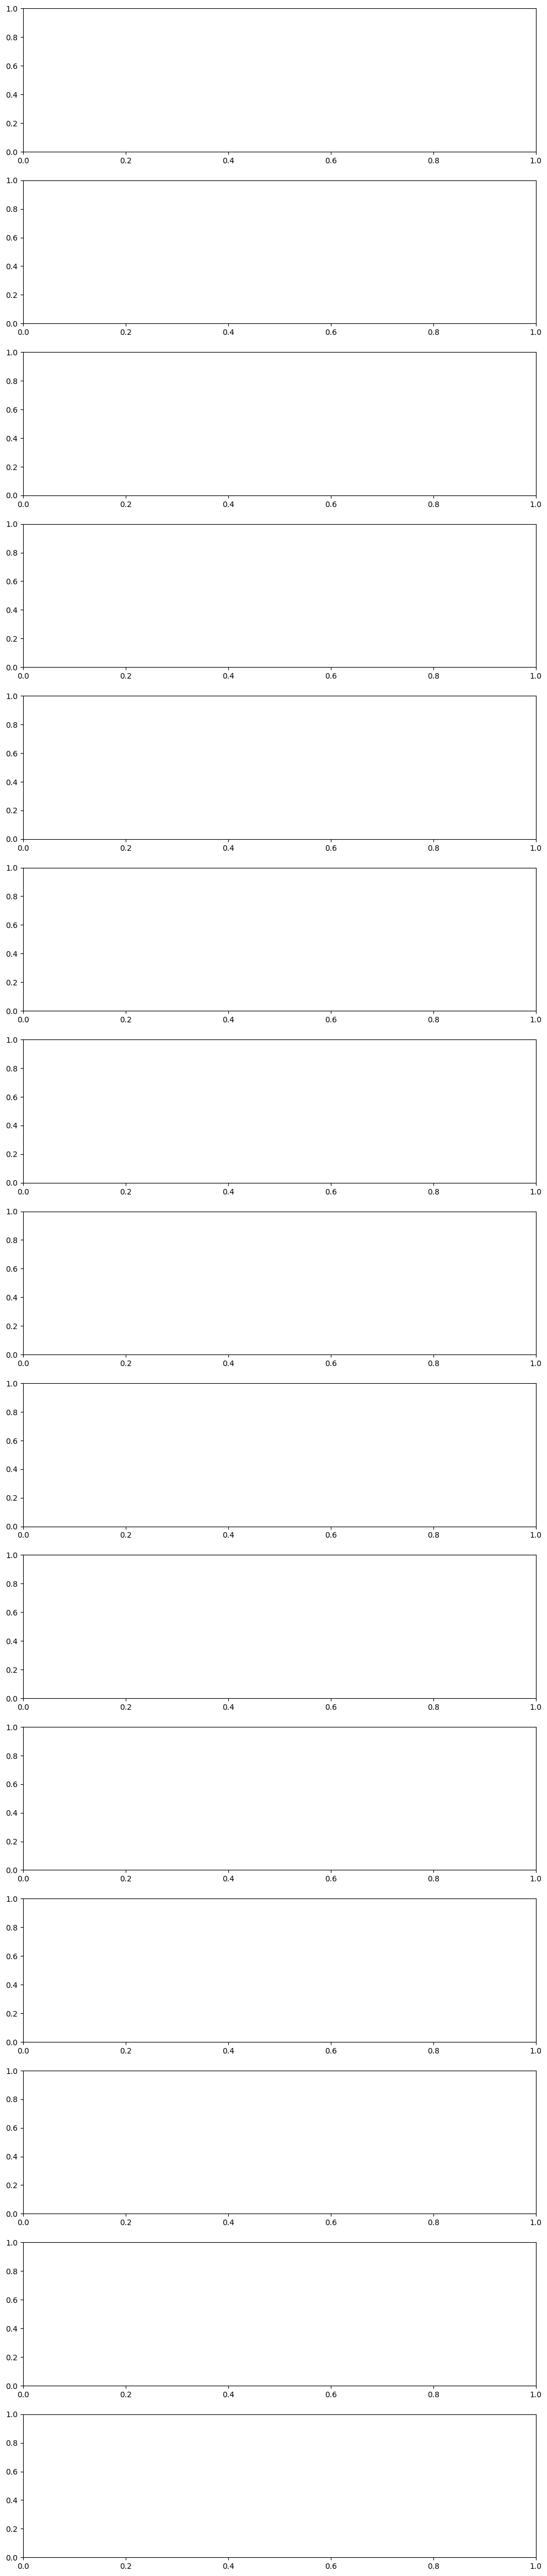

In [129]:
def plot_neuron_betas(model_output_all, neuron_indices, predictor_groups=None):
    """
    Plot beta weights for specified neurons from model output
    
    Parameters:
    - model_output_all: dictionary with fold-wise model outputs
    - neuron_indices: list/array of neuron indices to plot
    - predictor_groups: dictionary defining predictor groups and their indices (optional)
    """
    # Default predictor groups if none provided
    if predictor_groups is None:
        predictor_groups = {
            'left_turn': range(2, 6),
            'right_turn': range(41, 45),
            'sound_-90': range(140, 146),
            'sound_90': range(146, 152),
            'highlighted': range(176, 182), #range(176, 179)
            'opto_neurons': [n + 182 for n in opto_neurons],
            'sound_neurons': [n + 182 for n in sound_neurons]
        }
    
    # Get all fold IDs
    fold_ids = list(model_output_all.keys())
    
    # Create figure
    fig, axes = plt.subplots(len(neuron_indices), 1, 
                            figsize=(12, 4*len(neuron_indices)), 
                            squeeze=False)
    
    for n_idx, neuron in enumerate(neuron_indices):
        # Collect beta weights across folds for this neuron
        betas_across_folds = []
        for fold in fold_ids:
            betas = model_output_all[fold]['B_weights'][:, neuron]
            betas_across_folds.append(betas)
        
        # Calculate mean across folds
        mean_betas = np.mean(np.stack(betas_across_folds, axis=0), axis=0)
        
        # Create color array
        colors = ['silver'] * len(mean_betas)  # default color
        for group, indices in predictor_groups.items():
            if group == 'left_turn':
                color = 'cornflowerblue'
            elif group == 'right_turn':
                color = 'turquoise'
            elif group == 'sound_-90':
                color = 'orchid'
            elif group == 'sound_90':
                color = 'mediumvioletred'
            elif group == 'highlighted':
                color = 'orange'
            elif group == 'opto_neurons':
                color = 'gold'
            elif group == 'sound_neurons':
                color = 'blueviolet'
                
            for idx in indices:
                if idx < len(colors):
                    colors[idx] = color
        
        # Plot
        ax = axes[n_idx, 0]
        ax.bar(range(len(mean_betas)), mean_betas, color=colors)
        ax.set_xlabel('Feature Index')
        ax.set_ylabel('Beta Weight')
        ax.set_title(f'Beta Weights for Neuron {neuron}')
        
        # Add grid for better visibility
        ax.grid(True, alpha=0.3)
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=c, label=l) for l, c in [
                ('Left Turn', 'cornflowerblue'),
                ('Right Turn', 'turquoise'),
                ('Sound -90°', 'orchid'),
                ('Sound 90°', 'mediumvioletred'),
                ('Highlighted', 'orange'),
                ('Opto', 'gold'),
                ('Sound Neurons', 'blueviolet')
            ]
        ]
        ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    return fig, axes

# Example usage:
neuron_to_plot =  opto_neurons[8][0].tolist()#sound_neurons[8][0][np.arange(0,2)] # replace with your neuron index
fig, axes = plot_neuron_betas(model_output_all, neuron_to_plot)
plt.show()

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

def scatter_beta_vs_modindex(
    model_output_all,
    group_name,
    mod_index,
    neuron_indices,
    predictor_groups=None,
    xlabel=None,
    ylabel='Modulation Index',
    title=None,
    color='tab:blue',
    ylim=None
):
    """
    Scatter plot of average beta weight for a predictor group vs. modulation index for specified neurons.

    Parameters:
    - model_output_all: dict, fold-wise model outputs (with 'B_weights')
    - group_name: str, key in predictor_groups
    - mod_index: array-like, modulation index (1 x n_neurons or n_neurons)
    - neuron_indices: list of neuron indices to use
    - predictor_groups: dict of group_name: list of beta indices
    - xlabel: str, label for x-axis
    - ylabel: str, label for y-axis
    - title: str, plot title
    - color: str, color for scatter points
    """
    if predictor_groups is None:
        predictor_groups = {
            'left_turn': range(2, 6),
            'right_turn': range(41, 45),
            'sound_-90': range(140, 146),
            'sound_90': range(146, 152),
            'highlighted': range(176, 182),
            'opto_neurons': [n + 182 for n in opto_neurons],
            'sound_neurons': [n + 182 for n in sound_neurons]
        }

    fold_ids = list(model_output_all.keys())
    betas_per_neuron = []

    # # If neuron_indices not given, use all neurons based on B_weights shape in first fold
    # if neuron_indices_model is None:
    #     first_fold = fold_ids[0]
    #     n_neurons = model_output_all[first_fold]['B_weights'].shape[1]
    #     neuron_indices = list(range(n_neurons))

    for neuron in neuron_indices:
        # Collect beta weights across folds for this neuron
        betas_across_folds = []
        for fold in fold_ids:
            betas = model_output_all[fold]['B_weights'][:, neuron]
            betas_across_folds.append(betas)
        mean_betas = np.mean(np.stack(betas_across_folds, axis=0), axis=0)
        group_indices = predictor_groups[group_name]
        group_betas = [mean_betas[idx] for idx in group_indices if idx < len(mean_betas)]
        if len(group_betas) > 0:
            group_mean = np.mean(group_betas)
            betas_per_neuron.append(group_mean)
        else:
            betas_per_neuron.append(np.nan)

    # Prepare modulation index (flatten if needed)
    mod_index = np.array(mod_index).flatten()
    # Index into mod_index using neuron_indices
    mod_index_selected = np.array([mod_index[n] for n in neuron_indices])
    print(len(mod_index_selected), len(betas_per_neuron))

    # Remove NaNs for plotting
    betas_per_neuron = np.array(betas_per_neuron)
    mask = ~np.isnan(betas_per_neuron) & ~np.isnan(mod_index_selected)
    betas_plot = betas_per_neuron[mask]
    mod_index_plot = mod_index_selected[mask]

    # Scatter plot
    plt.figure(figsize=(4, 4))
    plt.scatter(betas_plot, mod_index_plot, color=color, alpha=0.7)

    # Regression line and correlation
    if len(betas_plot) > 1:
        slope, intercept, r_value, p_value, std_err = linregress(betas_plot, mod_index_plot)
        x_vals = np.array([betas_plot.min(), betas_plot.max()])
        plt.plot(x_vals, intercept + slope * x_vals, color='black', linestyle='--', linewidth=1)
        # Pearson correlation for display
        r, p = pearsonr(betas_plot, mod_index_plot)
        plt.text(0.05, 0.95, f"r={r:.2f}, p={p:.3g}", transform=plt.gca().transAxes,
                 ha='left', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


    plt.xlabel(xlabel if xlabel else f'Mean Beta: {group_name}')
    plt.ylabel(ylabel)
    if ylim is not None:
        plt.ylim(ylim)  # <-- Set y-limits if provided
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

    return betas_plot, mod_index_plot

{'pyr': [17, 39, 46, 47, 48, 53, 63, 69, 71, 73, 80, 81, 100, 102, 104, 106, 111, 123, 132, 136, 138, 140, 154, 155], 'som': [5, 16, 122, 147], 'pv': [32]}
[17, 39, 46, 47, 48, 53, 63, 69, 71, 73, 80, 81, 100, 102, 104, 106, 111, 123, 132, 136, 138, 140, 154, 155]
24 24


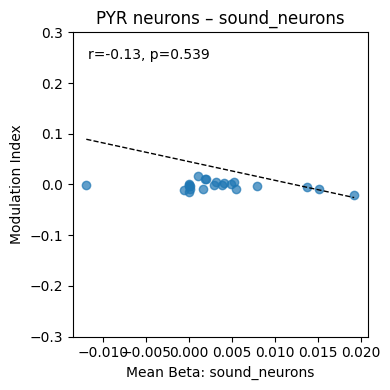

[5, 16, 122, 147]
4 4


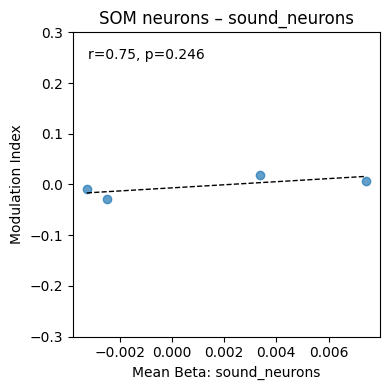

[32]
1 1


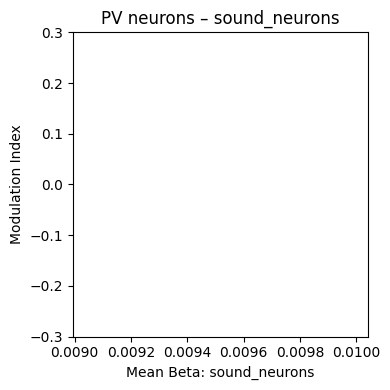

[17, 39, 46, 47, 48, 53, 63, 69, 71, 73, 80, 81, 100, 102, 104, 106, 111, 123, 132, 136, 138, 140, 154, 155]
24 24


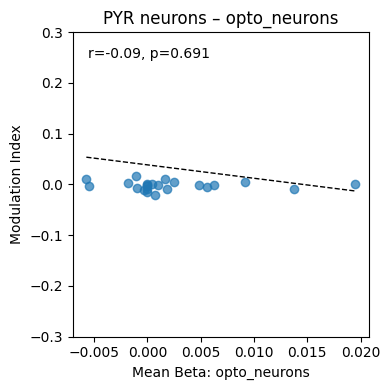

[5, 16, 122, 147]
4 4


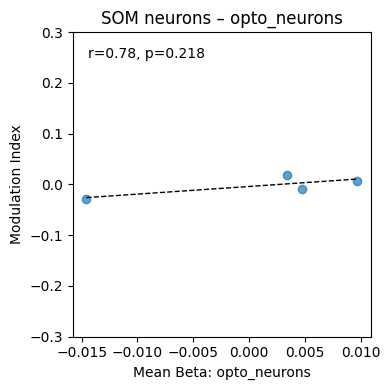

[32]
1 1


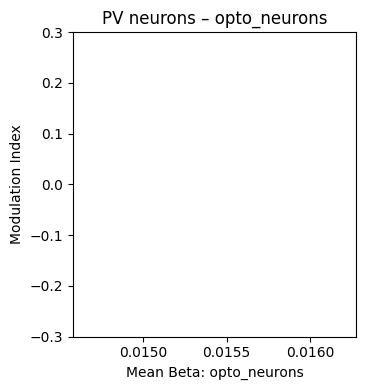

In [140]:
def split_neuron_indices_by_cell_type(cell_types, neuron_indices_model):
    cell_types = np.array(cell_types)
    neuron_indices_model = np.array(neuron_indices_model)
    pyr_indices = neuron_indices_model[cell_types[neuron_indices_model] == 0].tolist()
    som_indices = neuron_indices_model[cell_types[neuron_indices_model] == 1].tolist()
    pv_indices = neuron_indices_model[cell_types[neuron_indices_model] == 2].tolist()
    return {
        'pyr': pyr_indices,
        'som': som_indices,
        'pv': pv_indices
    }
# Assume you already have:
# - model_output_all
# - mod_index
# - cell_types (0 = pyr, 1 = som, 2 = pv)
# - neuron_indices_model (model-trained neuron indices)
# - opto_neurons and sound_neurons (used in predictor_groups)
# First, split neuron indices by cell type
cell_type_indices = split_neuron_indices_by_cell_type(celltype_array, sound_neurons[mouse_id][0].tolist())
print(cell_type_indices)
# Define predictor groups if not already defined
predictor_groups = {
    'left_turn': range(2, 6),
    'right_turn': range(41, 45),
    'sound_-90': range(140, 146),
    'sound_90': range(146, 152),
    'highlighted': range(176, 182),
    'opto_neurons': [n + 182 for n in  opto_neurons[mouse_id][0].tolist()],
    'sound_neurons': [n + 182 for n in  sound_neurons[mouse_id][0].tolist()]
}
# Plot for each group and cell type
for group_name in ['sound_neurons', 'opto_neurons']:
    cell_type_indices = split_neuron_indices_by_cell_type(celltype_array,  sound_neurons[mouse_id][0].tolist())
    for cell_type in ['pyr', 'som', 'pv']:
        indices = cell_type_indices[cell_type]
        print(indices)
        xlabel = f'Mean Beta: {group_name}'
        title = f'{cell_type.upper()} neurons – {group_name}'
        scatter_beta_vs_modindex(
            model_output_all=model_output_all,
            group_name=group_name,
            mod_index=mod_index[8][0],  # or mod_index.flatten()
            neuron_indices=indices,
            predictor_groups=predictor_groups,
            xlabel=xlabel,
            ylabel='Modulation Index',
            title=title,
            color='tab:blue',
            ylim=(-0.3, 0.3)  # optional, adjust as needed
        )

24 24


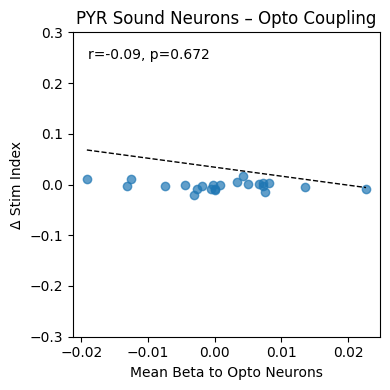

4 4


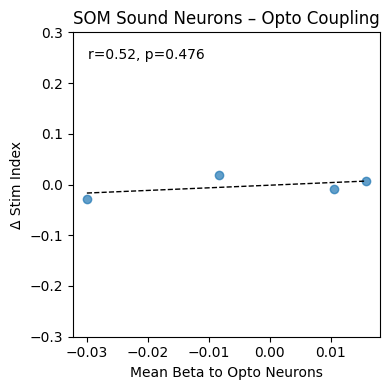

1 1


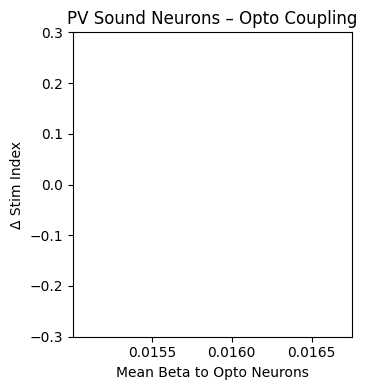

In [145]:
# Only analyze sound neurons and their beta weights to opto predictors
cell_type_indices = split_neuron_indices_by_cell_type(celltype_array,  sound_neurons[mouse_id][0].tolist())
# Define predictor groups if not already defined
predictor_groups = {
    'left_turn': range(2, 6),
    'right_turn': range(41, 45),
    'sound_-90': range(140, 146),
    'sound_90': range(146, 152),
    'highlighted': range(176, 182),
    'opto_neurons': [n + 182 for n in  opto_neurons[mouse_id][0].tolist()],
    'sound_neurons': [n + 182 for n in  sound_neurons[mouse_id][0].tolist()]
}
for cell_type in ['pyr', 'som', 'pv']:
    indices = cell_type_indices[cell_type]
    if len(indices) == 0:
        continue  # skip empty cell type group

    xlabel = f'Mean Beta to Opto Neurons'
    title = f'{cell_type.upper()} Sound Neurons – Opto Coupling'
    
    scatter_beta_vs_modindex(
        model_output_all=model_output_all,
        group_name='opto_neurons',  # <- the predictor group you're extracting weights from
        mod_index=mod_index[8][0],  # <- delta stim of sound neurons
        neuron_indices=indices,     # <- only sound neurons (split by type)
        predictor_groups=predictor_groups,
        xlabel=xlabel,
        ylabel='Δ Stim Index',
        title=title,
        color='tab:blue',
        ylim=(-0.3, 0.3)
    )


In [88]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# --- Step 1: Define predictor groups ---
predictor_groups = {
    'opto_neurons': [n + 182 for n in opto_neurons],
    'sound_neurons': [n + 182 for n in sound_neurons]
}

# --- Step 2: Collect data across sound neurons ---
def get_mean_betas(model_output_all, neuron_indices_model, predictor_group_indices):
    """
    Returns mean beta values for each neuron across folds for the given predictor group.
    """
    fold_ids = list(model_output_all.keys())
    mean_betas_all_neurons = []

    for neuron in neuron_indices_model:
        betas_across_folds = []
        for fold in fold_ids:
            betas = model_output_all[fold]['B_weights'][:, neuron]
            betas_across_folds.append(betas)
        mean_betas = np.mean(np.stack(betas_across_folds, axis=0), axis=0)
        group_betas = [mean_betas[idx] for idx in predictor_group_indices if idx < len(mean_betas)]
        mean_betas_all_neurons.append(np.mean(group_betas) if group_betas else np.nan)

    return np.array(mean_betas_all_neurons)

# --- Step 3: Prepare dataframe for model ---
# Get beta weights for opto predictor group
beta_opto = get_mean_betas(model_output_all, sound_neurons, predictor_groups['opto_neurons'])

# Get Δ stim modulation index (assumes passive index at mod_index[8][0])
mod_index_flat = np.array(mod_index[8][0][0])
delta_stim = mod_index_flat[sound_neurons]

# Get cell type labels for sound neurons
cell_type_labels = []
for i in sound_neurons:
    val = celltype_array[i]
    if val == 0:
        cell_type_labels.append('pyr')
    elif val == 1:
        cell_type_labels.append('som')
    elif val == 2:
        cell_type_labels.append('pv')
    else:
        cell_type_labels.append('unknown')

# Construct dataframe
df = pd.DataFrame({
    'delta_stim': delta_stim,
    'beta_opto': beta_opto,
    'cell_type': cell_type_labels
})
df = df.dropna()  # drop NaNs just in case

# Convert to categorical
df['cell_type'] = df['cell_type'].astype('category')

# --- Step 4: Run linear model with interaction ---
model = smf.ols('delta_stim ~ beta_opto * cell_type', data=df).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             delta_stim   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.801
Date:                Thu, 10 Jul 2025   Prob (F-statistic):              0.116
Time:                        18:34:35   Log-Likelihood:                 228.12
No. Observations:                 148   AIC:                            -444.2
Df Residuals:                     142   BIC:                            -426.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

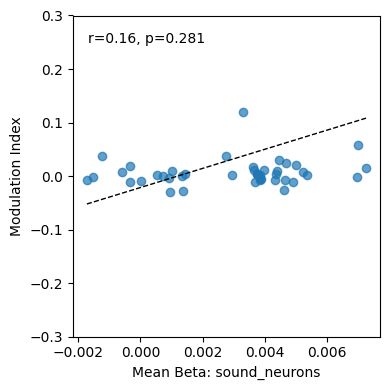

In [34]:
betas, mods = scatter_beta_vs_modindex(
    model_output_all=model_output_og_opto,
    group_name='sound_neurons',
    mod_index=mod_index[8][0],  # or mod_index.flatten()
    neuron_indices=sound_neurons,
    ylim=(-.3,.3)  # Set your desired y-limits here  
)

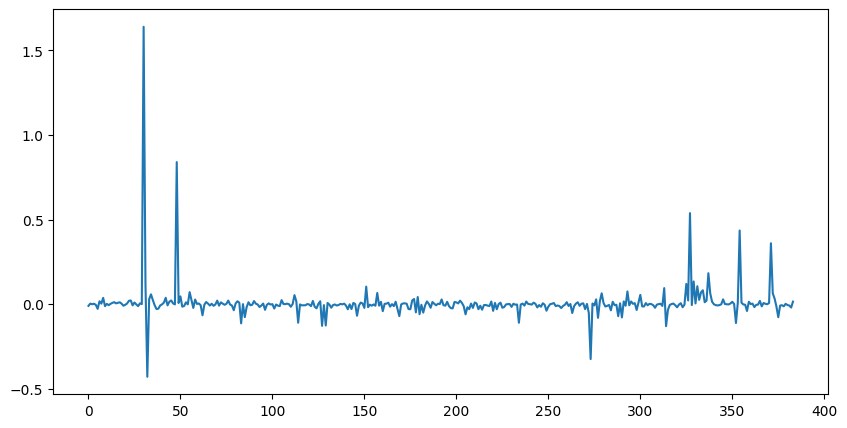

In [33]:
#plot all modulation indeces together
plt.figure(figsize=(10, 5)) 
plt.plot(mod_index[8][0][0], label=f'Mod Index {i}')

plt.show()

In [53]:
len(np.where(mod_index[8][0][0][sound_neurons] < 0)[0])

93

In [8]:
response_type = 'diff_stim' #diff_stim, avg_ctrl_post, avg_ctrl_pre
dir1 = f'V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\{response_type}.mat'
responder_type = 'sound_only_sig_cells'
dir2 = f'V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\{responder_type}.mat' #sound_only_sig_cells, opto_only_sig_cells,opto_sound_sig_cells,unmodulated
import scipy
# Load specific modulation indices!!
mod_idx = scipy.io.loadmat(dir1)
mod_index = mod_idx[response_type]
sig_cels = scipy.io.loadmat(dir2)
sig_cells = sig_cels[responder_type][0]-1 #minus one bc of MATLAB indexing
sig_cells = sig_cells.T
context = 0 #active = 0, passive = 1
print(f'shape sig_cells: {sig_cells.shape}')  # Check the shape of sig_cells

# Load the condition_array_trials structure

mat_data = scipy.io.loadmat('V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\info.mat')
info = mat_data['info'][0][0]
# Assuming your mouse_date structure is loaded as a numpy array
mouse_dates = [
    item[0].replace('\\', '_').replace('/', '_')  # Replace slashes with underscores for consistency
    for item in info['mouse_date'][0]
]
print(mouse_dates)

print(f'shape mod_index: {mod_index.shape}')  # Check the shape of mod_index
# Create an empty dictionary to store the significant neurons for each mouse_date
significant_neurons = {}
mod_index_neurons = {}
# Iterate over the mouse_dates and map to corresponding neurons in sig_cells by index
for idx, mouse_date in enumerate(mouse_dates):
    if idx < len(sig_cells):
        # Get the significant neurons for the current index
        significant_neurons_al = sig_cells[idx]
        # Store the results in a dictionary with mouse_date as the key
        significant_neurons[mouse_date] = significant_neurons_al
        current_mod = mod_index[idx][context] #[0,significant_neurons_al[0]]
        mod_index_neurons[mouse_date] = current_mod[0,significant_neurons_al[0]]#current_mod[significant_neurons_al[0]] #[0,significant_neurons_al[0]]
    else:
        print(f"No significant neurons found for {mouse_date}")

# Now you have a dictionary mapping each dataset to its significant neurons

print(f'total significant neurons: {len(sig_cells)}')

shape sig_cells: (24,)
['HA11-1R_2023-05-05', 'HA11-1R_2023-04-13', 'HA2-1L_2023-04-12', 'HA2-1L_2023-05-05', 'HA1-00_2023-06-29', 'HA1-00_2023-08-28', 'HE4-1L1R_2023-08-21', 'HE4-1L1R_2023-08-24', 'HA10-1L_2023-04-10', 'HA10-1L_2023-04-17', 'HA10-1L_2023-04-12', 'HA11-1R_2023-04-07', 'HA11-1R_2023-05-01', 'HA11-1R_2023-05-02', 'HA2-1L_2023-04-28', 'HA2-1L_2023-05-01', 'HA1-00_2023-06-27', 'HA1-00_2023-07-07', 'HA1-00_2023-08-25', 'HE4-1L1R_2023-08-14', 'HE4-1L1R_2023-08-28', 'HE4-1L1R_2023-09-04', 'HE4-1L1R_2023-09-11', 'HA10-1L_2023-03-31', 'HE1-00_2023-05-30']
shape mod_index: (25, 2)
No significant neurons found for HE1-00_2023-05-30
total significant neurons: 24


In [48]:
sig_cells[8][0].shape

(148,)

In [51]:
len(sound_neurons)

148

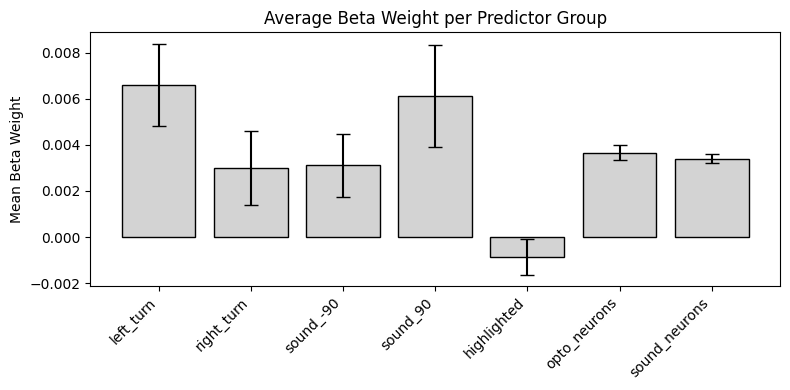

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_group_average_betas(model_output_all, neuron_indices=None, predictor_groups=None):
    """
    Plot the average beta weight for each predictor group, averaged per neuron then across neurons.
    """
    # Default predictor groups if none provided
    if predictor_groups is None:
        predictor_groups = {
            'left_turn': range(2, 6),
            'right_turn': range(41, 45),
            'sound_-90': range(140, 146),
            'sound_90': range(146, 152),
            'highlighted': range(176, 182),
            'opto_neurons': [n + 182 for n in opto_neurons],
            'sound_neurons': [n + 182 for n in sound_neurons]
        }

    fold_ids = list(model_output_all.keys())

    # If neuron_indices not given, use all neurons based on B_weights shape in first fold
    if neuron_indices is None:
        first_fold = fold_ids[0]
        n_neurons = model_output_all[first_fold]['B_weights'].shape[1]
        neuron_indices = list(range(n_neurons))

    group_means_per_neuron = {group: [] for group in predictor_groups}

    for neuron in neuron_indices:
        # Collect beta weights across folds for this neuron
        betas_across_folds = []
        for fold in fold_ids:
            betas = model_output_all[fold]['B_weights'][:, neuron]
            betas_across_folds.append(betas)
        mean_betas = np.mean(np.stack(betas_across_folds, axis=0), axis=0)

        # For each group, average the betas for the group's indices
        for group, indices in predictor_groups.items():
            group_betas = [mean_betas[idx] for idx in indices if idx < len(mean_betas)]
            if len(group_betas) > 0:
                group_mean = np.mean(group_betas)
                group_means_per_neuron[group].append(group_mean)
            else:
                group_means_per_neuron[group].append(np.nan)

    # Now average across neurons for each group
    group_names = list(predictor_groups.keys())
    means = [np.nanmean(group_means_per_neuron[group]) for group in group_names]
    sems = [np.nanstd(group_means_per_neuron[group]) / np.sqrt(np.sum(~np.isnan(group_means_per_neuron[group])))
            for group in group_names]

    # Plot
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(group_names))
    ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='k')
    ax.set_xticks(x)
    ax.set_xticklabels(group_names, rotation=45, ha='right')
    ax.set_ylabel('Mean Beta Weight')
    ax.set_title('Average Beta Weight per Predictor Group')
    plt.tight_layout()
    plt.show()

    return means, sems, group_means_per_neuron

# Example usage:
means, sems, group_means_per_neuron = plot_group_average_betas(model_output_og)

(<Figure size 1200x2000 with 5 Axes>,
 array([[<Axes: title={'center': 'Beta Weights for Neuron 0'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 10'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 15'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 20'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 25'}, xlabel='Feature Index', ylabel='Beta Weight'>]],
       dtype=object))

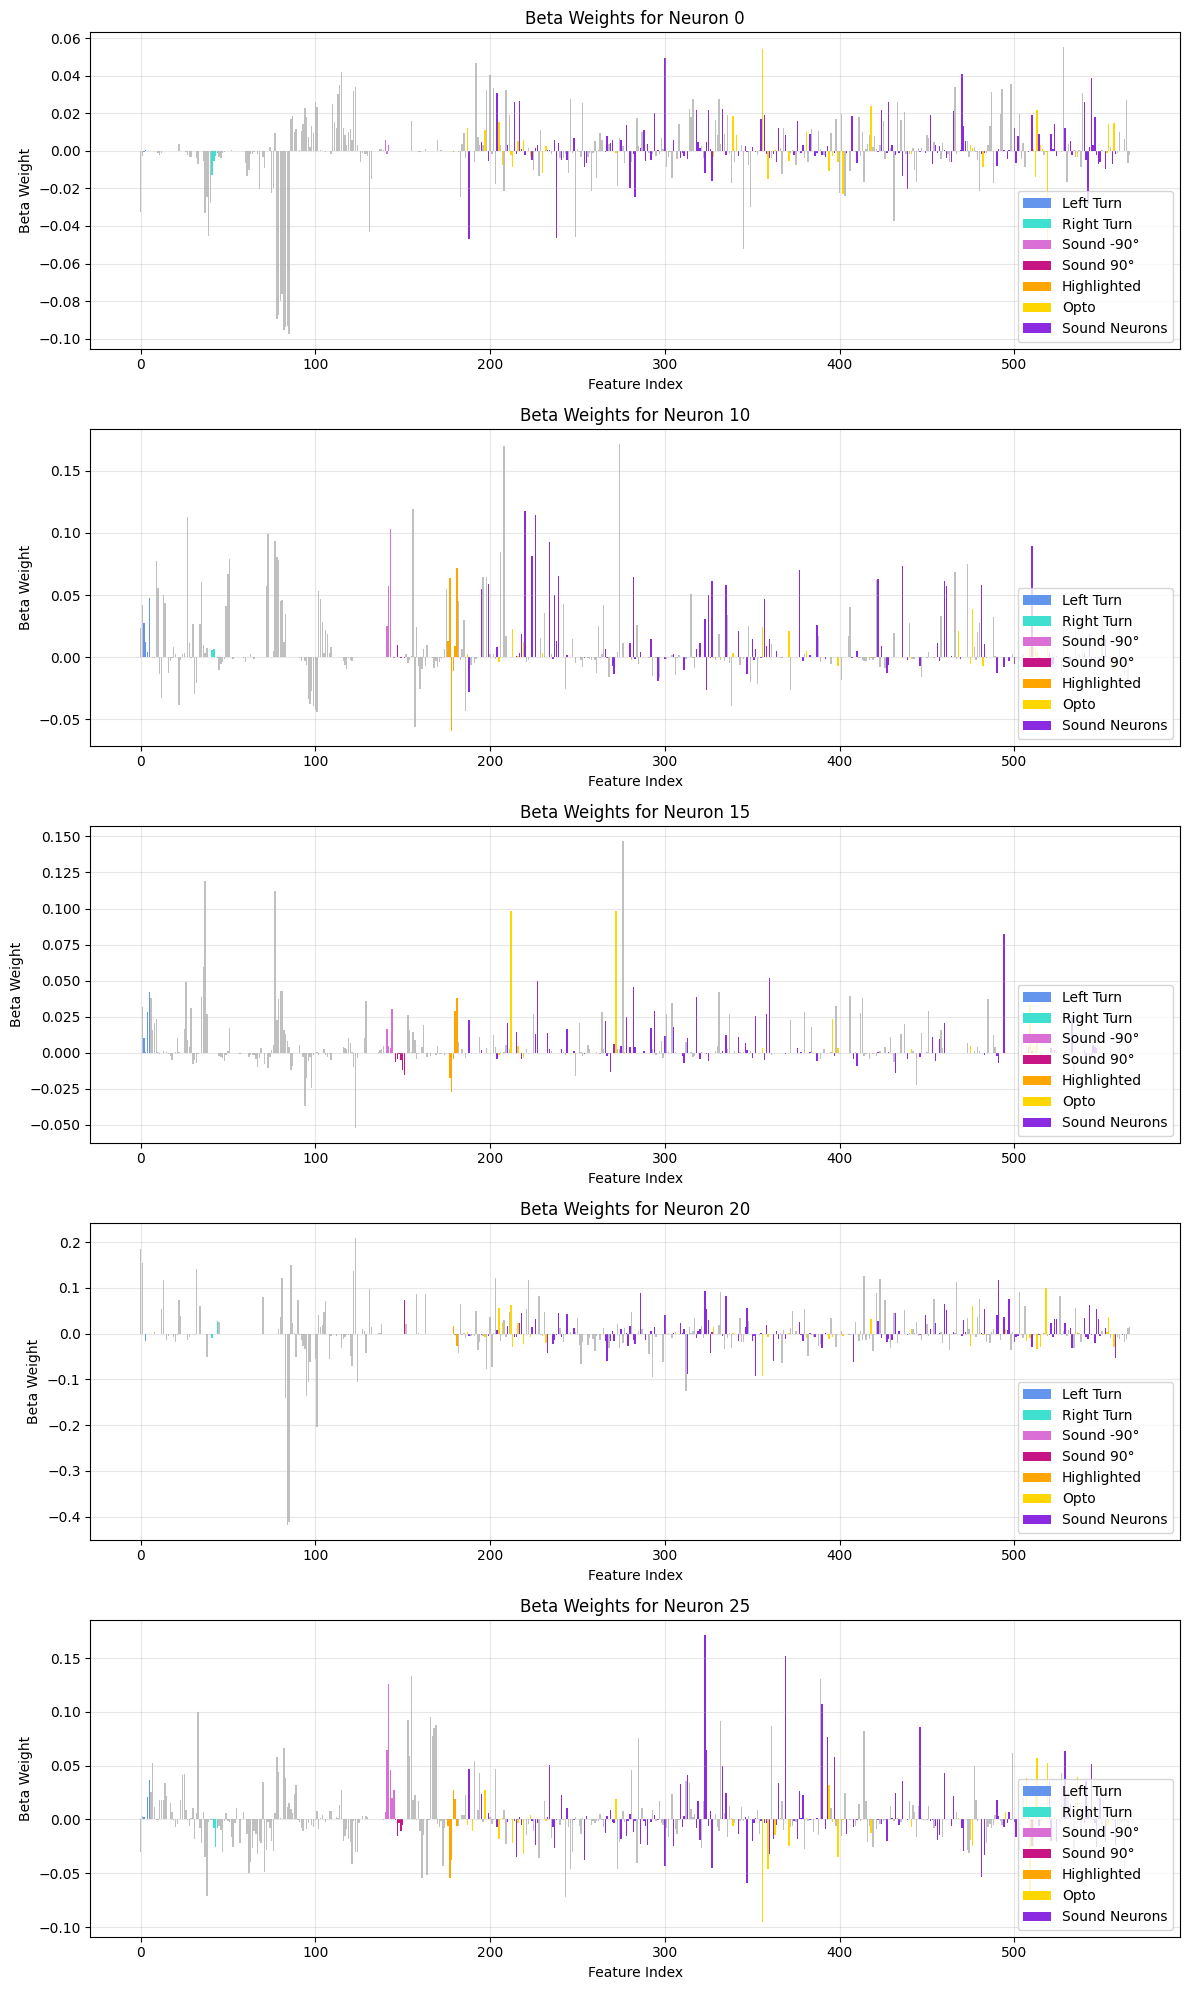

In [12]:
# Example usage:
neuron_idx = [0,10,15,20,25]  # replace with your neuron index
plot_neuron_betas(model_output_og,  neuron_idx)

(<Figure size 1200x3200 with 8 Axes>,
 array([[<Axes: title={'center': 'Beta Weights for Neuron 0'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 1'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 2'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 3'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 4'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 5'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 6'}, xlabel='Feature Index', ylabel='Beta Weight'>],
        [<Axes: title={'center': 'Beta Weights for Neuron 7'}, xlabel='Feature Index', ylabel='Beta Weight'>]],
       dtype=object))

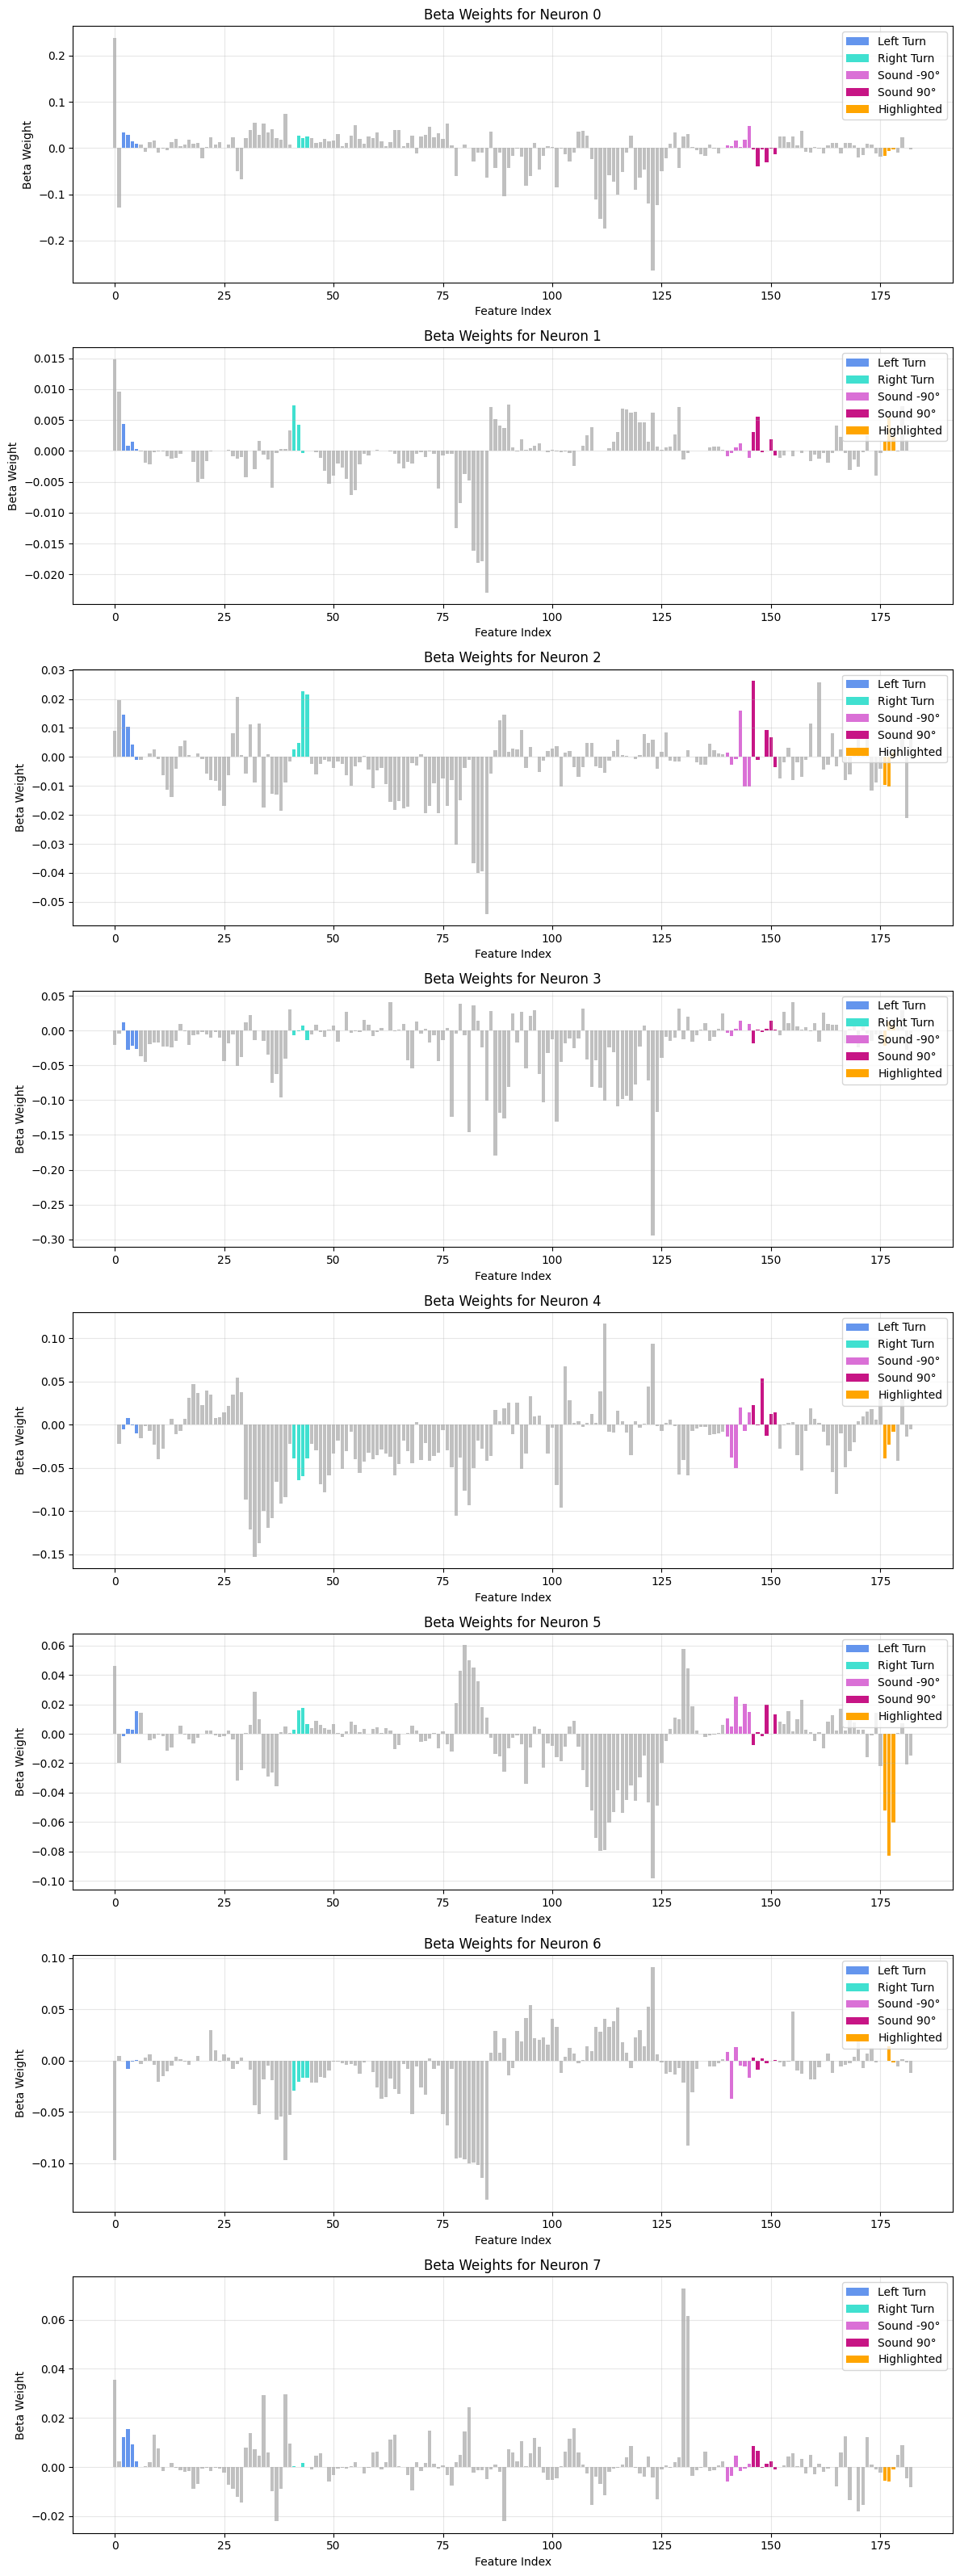

In [21]:
plot_neuron_betas(model_output_new,  neuron_idx)